In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset, random_split
import torch.nn as nn
import pandas as pd
import math

In [13]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
torch.set_default_device(DEVICE)

Using device: cuda


In [14]:
data = pd.read_csv('ranking_dataset.csv')
data.describe()
X = data.iloc[:, 0:10]
y = data.iloc[:, 10:20]
display(X.describe())
display(y.describe())
display(X.head())
display(y.head())

,val_0,val_1,val_2,val_3,val_4,val_5,val_6,val_7,val_8,val_9
count,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,500.537200,506.623500,501.396300,501.42390,493.817300,495.837500,501.616300,505.314100,500.361700,500.02570
std,290.444477,289.410167,288.372805,289.29438,289.255414,290.777883,288.663129,288.731189,288.747163,290.38134
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,248.000000,255.750000,256.000000,251.00000,244.000000,240.000000,250.750000,257.000000,249.000000,248.00000
50%,500.000000,511.000000,500.000000,505.00000,489.000000,496.000000,504.000000,504.000000,501.500000,501.00000
75%,755.000000,757.000000,752.250000,754.25000,745.000000,746.000000,753.250000,757.000000,752.000000,754.00000
max,999.000000,999.000000,999.000000,999.00000,999.000000,999.000000,999.000000,999.000000,999.000000,999.00000


,rank_0,rank_1,rank_2,rank_3,rank_4,rank_5,rank_6,rank_7,rank_8,rank_9
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.508600,4.546900,4.49630,4.511000,4.444500,4.443100,4.506400,4.544000,4.498000,4.501200
std,2.876031,2.888639,2.86056,2.866409,2.884086,2.878297,2.857022,2.867523,2.861261,2.882365
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2.00000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
50%,5.000000,5.000000,4.00000,5.000000,4.000000,4.000000,5.000000,5.000000,4.000000,4.000000
75%,7.000000,7.000000,7.00000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
max,9.000000,9.000000,9.00000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000


,val_0,val_1,val_2,val_3,val_4,val_5,val_6,val_7,val_8,val_9
0,542,67,876,414,26,335,620,924,950,113
1,378,14,210,954,231,572,315,295,567,706
2,749,876,73,111,899,213,541,769,287,219
3,372,880,475,329,733,564,739,376,632,10
4,186,822,577,519,707,123,143,294,693,677


,rank_0,rank_1,rank_2,rank_3,rank_4,rank_5,rank_6,rank_7,rank_8,rank_9
0,5,1,7,4,0,3,6,8,9,2
1,5,0,1,9,2,7,4,3,6,8
2,6,8,0,1,9,2,5,7,4,3
3,2,9,4,1,7,5,8,3,6,0
4,2,9,5,4,8,0,1,3,7,6


In [15]:
class RankingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


dataset = RankingDataset(X, y)
train_dataloader, test_dataloader, valid_dataloader = [
    DataLoader(x, batch_size=32, shuffle=True, generator=torch.Generator(DEVICE))
    for x in random_split(dataset, [0.6, 0.2, 0.2], generator=torch.Generator(DEVICE))
]

### Implementing a encoder-only transformer from scratch involves the following steps:
1. Get vectors for input tokens (here each token would just be the number)
2. Create positional encodings to add information about the position of each token in the sequence.
3. Define the multi-head self-attention mechanism to allow the model to focus on different parts of the input sequence.4. Implement the feed-forward neural network that processes the output of the attention mechanism.
5. Stack multiple layers of the attention and feed-forward networks to create a deep model.
6. Add layer normalization and residual connections to stabilize training and improve performance.
7. Define the output layer that maps the final hidden states to the desired output format (e.g., classification, regression).
8. Implement the training loop, including loss calculation, backpropagation, and optimization steps.
9. Evaluate the model on a validation set to monitor performance and prevent overfitting.
10. Fine-tune hyperparameters such as learning rate, batch size, and number of layers to achieve the best results.
11. Save the trained model for future inference and deployment.

In [16]:
# Implement the positional encoding layer
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()

        # Create a matrix of shape (max_len, 1) to hold the position indices
        position = torch.arange(max_len).unsqueeze(1)

        # Compute the divisor terms using a geometric progression
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        # Initialize a matrix of zeros for the positional encodings
        pe = torch.zeros(max_len, d_model)

        # Apply sine to even indices and cosine to odd indices
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Register as a buffer so it's saved with the model state but not updated by gradients
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Tensor, shape [batch_size, seq_len, d_model]
        """
        # Add the positional encodings to the input embeddings
        return x + self.pe[:, :x.size(1), :]

In [17]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, nhead: int, hidden_size: int = 512):
        super().__init__()
        self.d_model = d_model
        self.nhead = nhead
        self.hidden_size = hidden_size
        self.W_q = nn.ParameterList([nn.Parameter(torch.randn(d_model, hidden_size)) for _ in range(nhead)])  # n query weight matrices
        self.W_k = nn.ParameterList([nn.Parameter(torch.randn(d_model, hidden_size)) for _ in range(nhead)])  # n key weight matrices
        self.W_v = nn.ParameterList([nn.Parameter(torch.randn(d_model, hidden_size)) for _ in range(nhead)])  # n value weight matrices
        self.W_o = nn.Parameter(torch.randn(nhead * hidden_size, d_model))  # output weight matrix

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x shape: [batch_size, seq_len, d_model]
        # our weight matrices have shape [d_model, hidden_size], so we need to perform a matrix multiplication to get the queries, keys, and values
        del_vals = []
        for i in range(self.nhead):
            q = x @ self.W_q[i]  # shape: [batch_size, seq_len, hidden_size], these are all the queries
            k = x @ self.W_k[i]  # shape: [batch_size, seq_len, hidden_size], these are all the keys
            v = x @ self.W_v[i]  # shape: [batch_size, seq_len, hidden_size], these are all the values
            # dot product between queries and keys to get the attention scores
            attn_scores = q @ k.transpose(-2, -1) / math.sqrt(self.hidden_size)  # shape: [batch_size, seq_len, seq_len]
            attn_weights = torch.softmax(attn_scores, dim=-1)

            # Compute the output of the attention mechanism
            attn_output = torch.matmul(attn_weights, v)  # shape: [batch_size, seq_len, hidden_size]
            del_vals.append(attn_output)


        # Concatenate the outputs from all heads
        x = torch.cat(del_vals, dim=-1)  # shape: [batch_size, seq_len, nhead * hidden_size]
        # Apply the output weight matrix
        x = x @ self.W_o
        return x

In [18]:
class Model(nn.Module):
    def __init__(self, input_dim, output_dim, seq_len = 10, d_model=128, nhead=8, dim_feedforward=128, dropout=0.1):
        super(Model, self).__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        self.positional_encoding = PositionalEncoding(d_model)
        self.attention = MultiHeadAttention(d_model, nhead, hidden_size=d_model // nhead)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Linear(dim_feedforward, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.flatten = nn.Flatten() # we want to flatten the output of the attention mechanism to get a single vector for each sequence
        self.mlp = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, dim_feedforward),
            nn.Linear(dim_feedforward, output_dim)
        )

    def forward(self, x):
        # x shape: [batch_size, seq_len, input_dim]
        x = self.embedding(x)  # shape: [batch_size, seq_len, d_model]
        x = self.positional_encoding(x) # shape: [batch_size, seq_len, d_model]
        x = self.norm1(x + self.attention(x)) # shape: [batch_size, seq_len, d_model]
        x = self.norm2(x + self.ffn(x)) # shape: [batch_size, seq_len, d_model]
        # We now have seq_len embeddings of size d_model for each token in the sequence. We can then apply a fully connected layer to each embedding to get predicted ranks
        x = self.mlp(x) # shape: [batch_size, seq_len, output_dim]
        return x

model = Model(input_dim=1, output_dim=10).to(DEVICE)

In [19]:
def train(model, train_dataloader, valid_dataloader, epochs=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = torch.nn.CrossEntropyLoss()

    losses = []
    valid_losses = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_dataloader:
            X_batch = X_batch.unsqueeze(-1).to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(X_batch)
            # print(outputs.shape, y_batch.shape)
            loss = criterion(outputs.permute(0, 2, 1), y_batch.long())  # CrossEntropyLoss expects input of shape [batch_size, num_classes, seq_len] and target of shape [batch_size, seq_len]
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        losses.append(total_loss / len(train_dataloader))
        print(f"Epoch {epoch+1}/{epochs}, Loss: {losses[-1]:.4f}")

        model.eval()
        with torch.no_grad():
            valid_loss = 0
            for X_batch, y_batch in valid_dataloader:
                X_batch = X_batch.unsqueeze(-1).to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                outputs = model(X_batch)
                loss = criterion(outputs.permute(0, 2, 1), y_batch.long())
                valid_loss += loss.item()
        valid_losses.append(valid_loss / len(valid_dataloader))
        print(f"Validation Loss: {valid_losses[-1]:.4f}")

    return losses, valid_losses

Epoch 1/100, Loss: 2.3003
Validation Loss: 2.2963
Epoch 2/100, Loss: 2.2924
Validation Loss: 2.2978
Epoch 3/100, Loss: 2.3229
Validation Loss: 2.2995
Epoch 4/100, Loss: 2.3026
Validation Loss: 2.2996
Epoch 5/100, Loss: 2.2755
Validation Loss: 2.1879
Epoch 6/100, Loss: 1.9932
Validation Loss: 1.6913
Epoch 7/100, Loss: 2.1531
Validation Loss: 1.7588
Epoch 8/100, Loss: 1.8026
Validation Loss: 1.8103
Epoch 9/100, Loss: 1.7080
Validation Loss: 1.5352
Epoch 10/100, Loss: 1.6811
Validation Loss: 1.9325
Epoch 11/100, Loss: 1.5784
Validation Loss: 1.6844
Epoch 12/100, Loss: 1.5570
Validation Loss: 1.5068
Epoch 13/100, Loss: 1.7557
Validation Loss: 1.5388
Epoch 14/100, Loss: 1.5476
Validation Loss: 1.6469
Epoch 15/100, Loss: 1.4881
Validation Loss: 1.3429
Epoch 16/100, Loss: 1.4942
Validation Loss: 1.5094
Epoch 17/100, Loss: 1.4713
Validation Loss: 1.4861
Epoch 18/100, Loss: 1.5041
Validation Loss: 1.4056
Epoch 19/100, Loss: 1.4551
Validation Loss: 1.7285
Epoch 20/100, Loss: 1.4785
Validation Lo

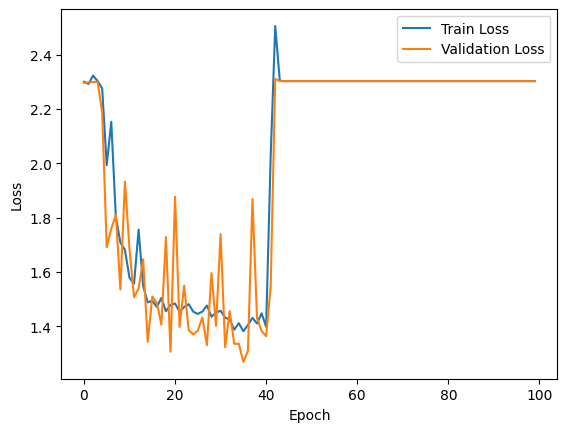

In [20]:
train_losses, valid_losses = train(model, train_dataloader, valid_dataloader, epochs=100)
torch.save(model.state_dict(), 'models/transformer.pth')
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [21]:
# Test the model on the test set
model.eval()
test_loss = 0
criterion = torch.nn.CrossEntropyLoss()
with torch.no_grad():
    for X_batch, y_batch in test_dataloader:
        X_batch = X_batch.unsqueeze(-1).to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        outputs = model(X_batch)
        loss = criterion(outputs.permute(0, 2, 1), y_batch.long())
        test_loss += loss.item()
test_loss /= len(test_dataloader)
print(f"Test Loss: {test_loss:.4f}")

Test Loss: 2.3026


Average accuracy on test set: 0.1000


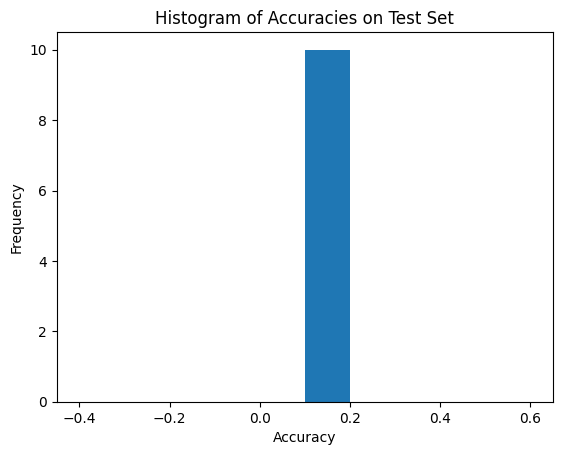

In [22]:
accuracies = []
for X_batch, y_batch in test_dataloader:
    output_logits = model(X_batch.unsqueeze(-1).to(DEVICE))
    predictions = torch.argmax(output_logits.permute(0, 2, 1), dim=1)  # Get the predicted ranks by taking the argmax along the output dimension
    accuracies.extend((predictions.cpu() == y_batch.cpu()).float().mean(dim=1).tolist())

# Plot histogram of accuracies:
print(f"Average accuracy on test set: {sum(accuracies) / len(accuracies):.4f}")
plt.hist(accuracies, bins=10, density=True)
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.title('Histogram of Accuracies on Test Set')
plt.show()